In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from GG4 import Brain

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    CAPTIONS_PATH,
    CVA_EM_COLOURS,
    CVA_EM_PATHS,
    DATA_DIR,
    ERA_EM_PATH,
    ERA_EM_2_PATH,
    ERA_EM_4_PATH,
    ERA_EM_6_PATH,
    ERA_EM_PATHS,
    ERA_EM_COLOURS,
    FIGURES_PATH,
    LATENT_DIMS,
    N_BURNIN,
    N_HANKEL_COLS,
    N_HANKEL_ROWS,
    N_MARKOV,
    RANDOM_SEED,
)
from id import NOTEBOOK_GITHUB_URL, fit_cva_em, fit_era_em, make_id_figure
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from system_estimate import SystemEstimate

In [2]:
# ── experiment constants ───────────────────────────────────────────────────────
ERA_DRIVE_SEED = 9      # RNG seed for ERA OLS input sequence
EM_SEED        = 2      # Brain seed for ERA+EM / CVA+EM time series
EM_DRIVE_SEED  = 42     # RNG seed for ERA+EM / CVA+EM random drive

N_SAMPLES   = 5000      # timesteps for training
HORIZON     = 30        # CVA+EM block-Hankel horizon
MAX_EM_ITER = 200
EM_TOL      = 1e-6

# Set this after inspecting freq_map and bode for n_x = 2, 4, 6.
# The chosen ERA+EM model is also saved to ERA_EM_PATH for downstream use.
CHOSEN_LATENT_DIM = 4

In [3]:
# ── derived: Brain dimensions ──────────────────────────────────────────────────
_b = Brain(random_seed=RANDOM_SEED)
P_DIM = _b.input_dim
Q_DIM = len(_b.measure())
del _b

print(f"n_u = {P_DIM}")
print(f"n_y = {Q_DIM}")
print(f"Fitting ERA+EM for n_x in {LATENT_DIMS}")

n_u = 2
n_y = 16
Fitting ERA+EM for n_x in [2, 4, 6]


In [4]:
# ── simulation: fit ERA+EM and CVA+EM for each latent dimension ────────────────
# This cell is expensive (~6 EM runs). Expect several minutes.
ERA_ESTIMATES:  dict[int, SystemEstimate] = {}
CVA_ESTIMATES:  dict[int, SystemEstimate] = {}

for n_x, colour in zip(LATENT_DIMS, ERA_EM_COLOURS):
    print(f"\n=== ERA+EM  n_x = {n_x} ===")
    est, logliks = fit_era_em(
        era_seed=RANDOM_SEED,
        era_drive_seed=ERA_DRIVE_SEED,
        n_u=P_DIM,
        n_y=Q_DIM,
        n_latent=n_x,
        n_markov=N_MARKOV,
        n_hankel_rows=N_HANKEL_ROWS,
        n_hankel_cols=N_HANKEL_COLS,
        em_seed=EM_SEED,
        em_drive_seed=EM_DRIVE_SEED,
        n_samples=N_SAMPLES,
        n_burnin=N_BURNIN,
        max_em_iter=MAX_EM_ITER,
        em_tol=EM_TOL,
        colour=colour,
    )
    ERA_ESTIMATES[n_x] = SystemEstimate(
        name=f"era_em_{n_x}",
        label=rf"ERA+EM $n_x={n_x}$",
        colour=colour,
        A=est.A, B=est.B, C=est.C, Q=est.Q, R=est.R,
    )
    sr = float(np.max(np.abs(np.linalg.eigvals(ERA_ESTIMATES[n_x].A))))
    print(f"  spectral radius = {sr:.4f}  EM iters = {len(logliks)}")

for n_x, colour in zip(LATENT_DIMS, CVA_EM_COLOURS):
    print(f"\n=== CVA+EM  n_x = {n_x} ===")
    est, logliks = fit_cva_em(
        seed=EM_SEED,
        drive_seed=EM_DRIVE_SEED,
        n_latent=n_x,
        n_samples=N_SAMPLES,
        n_burnin=N_BURNIN,
        horizon=HORIZON,
        max_em_iter=MAX_EM_ITER,
        em_tol=EM_TOL,
        colour=colour,
    )
    CVA_ESTIMATES[n_x] = SystemEstimate(
        name=f"cva_em_{n_x}",
        label=rf"CVA+EM $n_x={n_x}$",
        colour=colour,
        A=est.A, B=est.B, C=est.C, Q=est.Q, R=est.R,
    )
    sr = float(np.max(np.abs(np.linalg.eigvals(CVA_ESTIMATES[n_x].A))))
    print(f"  spectral radius = {sr:.4f}  EM iters = {len(logliks)}")

# Keep ESTIMATES pointing to the chosen ERA+EM for display/caption cells below
ESTIMATES = ERA_ESTIMATES


=== ERA+EM  n_x = 2 ===


EM refinement:   0%|          | 0/200 [00:00<?, ?iter/s]

  spectral radius = 0.9424  EM iters = 26

=== ERA+EM  n_x = 4 ===


EM refinement:   0%|          | 0/200 [00:00<?, ?iter/s]

  spectral radius = 0.9719  EM iters = 45

=== ERA+EM  n_x = 6 ===


...

  spectral radius = 0.9422  EM iters = 14

=== CVA+EM  n_x = 4 ===


EM refinement:   0%|          | 0/200 [00:00<?, ?iter/s]

  spectral radius = 0.9410  EM iters = 36

=== CVA+EM  n_x = 6 ===


EM refinement:   0%|          | 0/200 [00:00<?, ?iter/s]

  spectral radius = 0.9408  EM iters = 57


In [5]:
# ── save identified matrices ───────────────────────────────────────────────────
DATA_DIR.mkdir(parents=True, exist_ok=True)

for n_x, path in zip(LATENT_DIMS, ERA_EM_PATHS):
    ERA_ESTIMATES[n_x].save(path)
    print(f"ERA+EM n_x={n_x}  saved to {path.resolve()}")

for n_x, path in zip(LATENT_DIMS, CVA_EM_PATHS):
    CVA_ESTIMATES[n_x].save(path)
    print(f"CVA+EM n_x={n_x}  saved to {path.resolve()}")

# Save chosen ERA+EM to ERA_EM_PATH for downstream notebooks.
ERA_ESTIMATES[CHOSEN_LATENT_DIM].save(ERA_EM_PATH)
print(f"\nChosen ERA+EM n_x={CHOSEN_LATENT_DIM} also saved to {ERA_EM_PATH.resolve()}")

ERA+EM n_x=2  saved to /Users/tahmidazam/Developer/gg4/data/era_em_2_matrices.npz
ERA+EM n_x=4  saved to /Users/tahmidazam/Developer/gg4/data/era_em_4_matrices.npz
ERA+EM n_x=6  saved to /Users/tahmidazam/Developer/gg4/data/era_em_6_matrices.npz
CVA+EM n_x=2  saved to /Users/tahmidazam/Developer/gg4/data/cva_em_2_matrices.npz
CVA+EM n_x=4  saved to /Users/tahmidazam/Developer/gg4/data/cva_em_4_matrices.npz
CVA+EM n_x=6  saved to /Users/tahmidazam/Developer/gg4/data/cva_em_6_matrices.npz

Chosen ERA+EM n_x=4 also saved to /Users/tahmidazam/Developer/gg4/data/era_em_matrices.npz


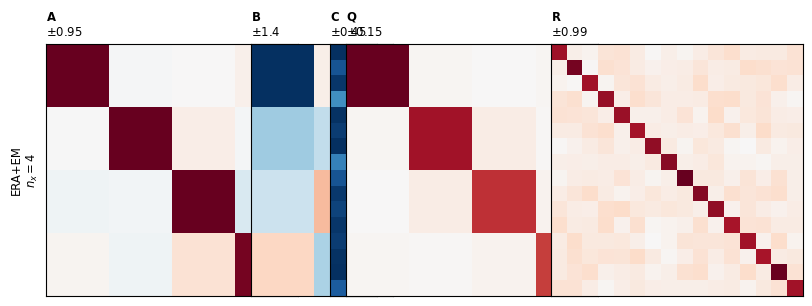

In [6]:
# ── display ────────────────────────────────────────────────────────────────────
configure_screen()
fig = make_id_figure([ESTIMATES[CHOSEN_LATENT_DIM]], figsize=(8, 3))
apply_figure_style(fig)
plt.show()

In [7]:
# ── pgf export ─────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 0.5   # fraction of A4 content width
FIG_HEIGHT_FRAC = 0.10  # fraction of A4 content height (1 row)

configure_pgf()
fig = make_id_figure(
    [ESTIMATES[CHOSEN_LATENT_DIM]],
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "id.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/id.pgf


In [8]:
# ── caption ────────────────────────────────────────────────────────────────────
caption = (
    r"Identified system matrices $A$, $B$, $C$, $Q$, $R$ of the chosen model. "
    r"Diverging colour scale is symmetric about zero."
)
save_caption(CAPTIONS_PATH / "id.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)


Saved caption to /Users/tahmidazam/Developer/gg4/captions/id.tex
Identified system matrices $A$, $B$, $C$, $Q$, $R$ of the chosen model. Diverging colour scale is symmetric about zero.
